### Create data set and plot

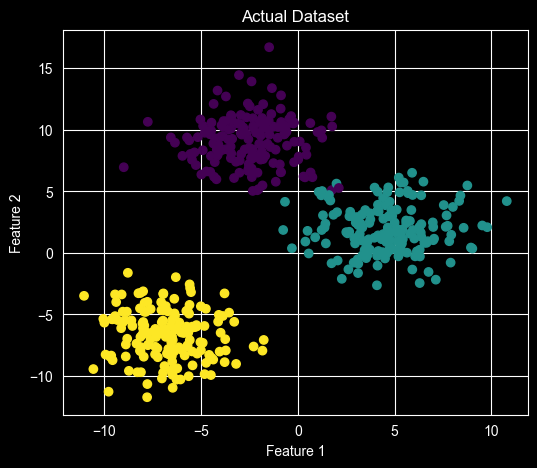

In [1]:
from matplotlib import pyplot as plt
from sklearn.datasets import make_blobs

X, y = make_blobs(
    n_samples=500,
    centers=3,
    random_state=42,
    cluster_std=2
)

# --------------------------
# 2 Plot actual dataset
# --------------------------
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=y, cmap="viridis")
plt.title("Actual Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

### Random forest training

In [2]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# --------------------------
# 3 Train test split
# --------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# --------------------------
# 4 RandomForest + GridSearch
# --------------------------
param_grid = {
    "n_estimators":[50,100,150],
    "max_depth":[3,5,8],
    "max_features":["sqrt","log2"]
}

rf = RandomForestClassifier()

grid = GridSearchCV(
    rf,
    param_grid,
    cv=5
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 3, 'max_features': 'sqrt', 'n_estimators': 100}


### Prediction and accuracy

In [3]:
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.preprocessing import label_binarize

# --------------------------
# 5 Predictions
# --------------------------
y_pred = best_model.predict(X_test)

# --------------------------
# 6 Accuracy
# --------------------------
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# --------------------------
# 7 ROC AUC (multi class)
# --------------------------
y_test_bin = label_binarize(y_test, classes=[0,1,2])
y_prob = best_model.predict_proba(X_test)

roc_auc = roc_auc_score(
    y_test_bin,
    y_prob,
    multi_class="ovr"
)

print("ROC AUC:", roc_auc)

Accuracy: 0.9866666666666667
ROC AUC: 0.9998591601412598


### Decission boundary

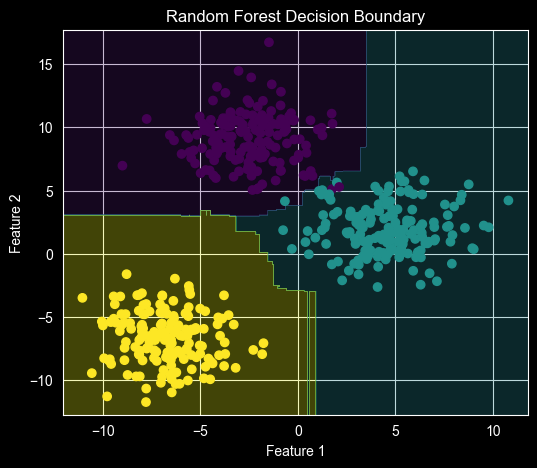

In [5]:
import numpy as np

h = 0.02

x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
y_min, y_max = X[:,1].min()-1, X[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

Z = best_model.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

plt.figure(figsize=(6,5))

plt.contourf(xx, yy, Z, alpha=0.3, cmap="viridis")

plt.scatter(X[:,0], X[:,1], c=y, cmap="viridis")

plt.title("Random Forest Decision Boundary")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.show()